# Customer Segmentation with K-Means and PCA

**Goal:** Use K-Means to divide a customer base into distinct groups (clusters) based on purchasing or usage metrics, and use PCA to reduce the data dimensions, enabling visualization of these clusters.

### 1. Data Loading and Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import seaborn as sns

# PLEASE UPLOAD 'online_retail_II.csv' TO THE SAME DIRECTORY AS THIS NOTEBOOK
try:
    data = pd.read_csv('online_retail_II.csv')
    print('Dataset loaded successfully!')
except FileNotFoundError:
    print('Please upload online_retail_II.csv to the same directory as this notebook.')

Dataset loaded successfully!


### 2. Data Cleaning

In [2]:
# Remove rows with missing Customer ID
data.dropna(axis=0, subset=['Customer ID'], inplace=True)

# Remove cancelled orders
data = data[~data['Invoice'].str.contains('C', na=False)]

# Create 'TotalPrice' column
data['TotalPrice'] = data['Quantity'] * data['Price']

# Create RFM features
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])
snapshot_date = data['InvoiceDate'].max() + pd.DateOffset(days=1)
rfm = data.groupby(['Customer ID']).agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
})

# Rename columns
rfm.rename(columns={'InvoiceDate': 'Recency', 'Invoice': 'Frequency', 'TotalPrice': 'MonetaryValue'}, inplace=True)

### 3. Feature Scaling

In [3]:
# Scale the RFM features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

### 4. K-Means Clustering

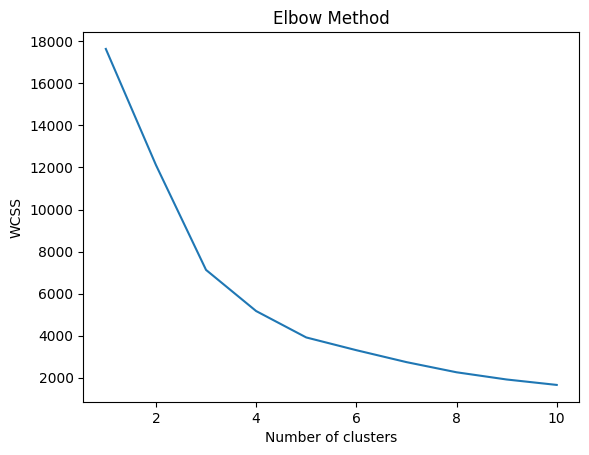

In [4]:
# Determine the optimal number of clusters using the Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [5]:
# Fit K-Means with the optimal number of clusters (let's assume 4)
kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=0)
clusters = kmeans.fit_predict(rfm_scaled)

### 5. PCA for Visualization

In [6]:
# Reduce dimensionality to 2 components for visualization
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

### 6. Cluster Visualization

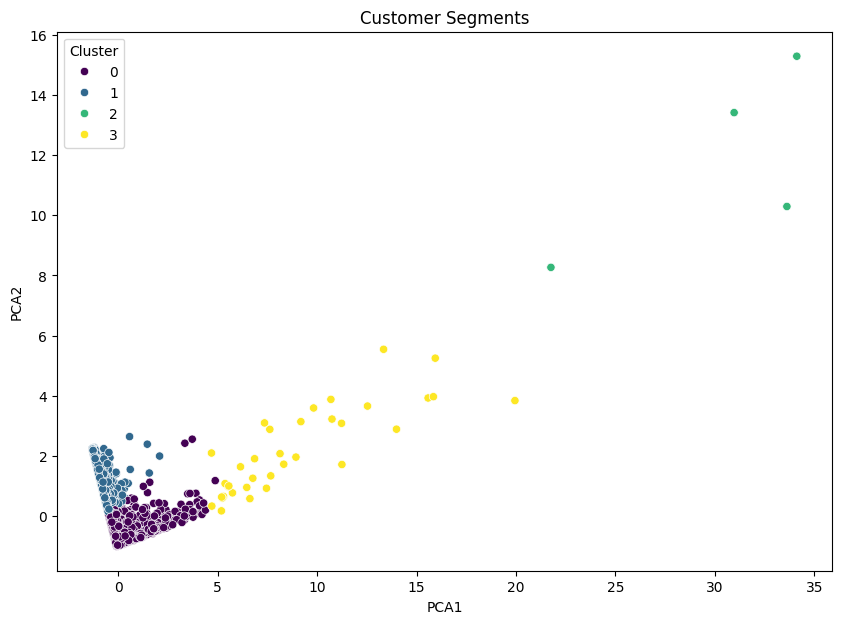

In [7]:
# Create a DataFrame with the PCA results and cluster labels
pca_df = pd.DataFrame(data=rfm_pca, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = clusters

# Visualize the clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=pca_df, palette='viridis')
plt.title('Customer Segments')
plt.show()